In [1]:
include("BarrierSynthesis.jl")
# include("PlotBarriers.jl")

compute_next_level_barriersPM (generic function with 1 method)

In [2]:
@polyvar u[1:2]
@polyvar(x[1:6]) # x[1] is x, x[2] is y, x[3] is vel, x[4] is θ, x[5] is ω, x[6] is error
    dynamics = [
        (ctrl -> [x[3]*(2.0/π)*(x[4] + π/2.0)-0.2x[6],x[3]*(-2.0/π)*(x[4]+π)-0.2x[6], ctrl[1], x[5], ctrl[2], 0.]),
        (ctrl -> [x[3]*(2.0/π)*(x[4] + π/2.0)-0.2x[6],x[3]*(2.0/π)*x[4]+0.2x[6], ctrl[1], x[5], ctrl[2], 0]),
        (ctrl -> [x[3]*(-2.0/π)*(x[4] - π/2.0)+0.2x[6],x[3]*(2.0/π)*x[4]+0.2x[6], ctrl[1], x[5], ctrl[2], 0]),
        (ctrl -> [x[3]*(-2.0/π)*(x[4] - π/2.0)+0.2x[6],x[3]*(-2.0/π)*(x[4]-π)-0.2x[6], ctrl[1], x[5], ctrl[2], 0]),
    ]
g = 0.1^2 - x[1]^2 - x[2]^2 # Obstacle: is a (x,y) ball of radius 0.1 around origin
bounds = [[-20., 20.], [-20., 20.], [-20.,20.],[-π,π], [-20.,20.],[-1.,1.]]

6-element Vector{Vector{Float64}}:
 [-20.0, 20.0]
 [-20.0, 20.0]
 [-20.0, 20.0]
 [-3.141592653589793, 3.141592653589793]
 [-20.0, 20.0]
 [-1.0, 1.0]

In [3]:
# λ = 1
K =1.5
δ = 0.5
ϵ = 0.02
α = 0.6
max_degree=2
U = [[-3., -3.], [-3., 3.], [3., -3.], [3., 3.]]
# U = [[-5., -5.], [-5., 5.], [5., -5.], [5., 5.]]
n_tests = 200

200

In [4]:
test_pts = [ get_random(bounds, g) for _ in 1:n_tests]

200-element Vector{Vector{Float64}}:
 [11.515914176619372, -10.484990889643061, 13.701072583556872, -0.20638409777152056, 18.841856429350372, -0.03584009721915615]
 [-3.709905541596715, -0.8210032541667225, -7.906707713622145, 2.492874261024795, 11.949974356645239, -0.7739319530541209]
 [-14.161485014645194, 9.576949411309354, -14.096720040977896, 2.755350820275358, 0.7162749098205765, 0.7981461365739819]
 [7.2447623673528625, 1.4492294768340308, -8.774831545414013, 2.952870099456514, 0.34238695711657385, 0.335087655791364]
 [3.5265858232351164, 17.722379488825737, -14.129286373715875, -3.1135065179321626, -10.186030644761509, -0.19272637707418605]
 [17.79997081080984, 6.368689220290111, -5.364086910370428, -1.9979919935035502, 8.415220246515421, -0.5309649408661379]
 [-5.528271146244062, -9.960477171428685, -7.628495486444349, 2.100972636202913, 0.5764554099729651, -0.07505169417782542]
 [-6.309321882566682, 0.6759092993565652, 5.777705183695744, 0.13570324472995532, 14.14435546576370

In [5]:
function findRepulsiveBarrier_HybridCT(x, ctrl::Vector{Float64}, g, dynamics, test_pts; max_degree=4, ϵ=1.0, τ=0.1, γ=10.0, K=1.0, δ=1.0, α=1.0, state_bounds=bounds)
    function prepare_domain_hybrid(var, lb, ub)
        dom = @set(var >= lb) ∩ @set(var <= ub) ∩ @set((var - lb) * (ub - var) >= 0)
        return dom
    end

    @assert τ > 0.0 "τ must be positive."
    @assert δ > 0.0 "δ must be positive."
    @assert K >= 0.0 "K must be nonnegative."
    @assert α > 0.0 "α must be positive."

    λ = (1.0 / τ) * log(1.0 + K / δ)

    solver = optimizer_with_attributes(MosekTools.Optimizer)
    model = SOSModel(solver)
    monos = monomials(x, 0:max_degree)
    N = length(monos)
    @variable(model, -γ <= c[1:N] <= γ)
    B = polynomial(c[1:end], monos)

    dom_list = prepare_domain(x, state_bounds)
    D = reduce((s1, s2) -> s1 ∩ s2, dom_list)
    println("Domain: $D")

    # 1) Unsafe-set positivity on obstacle states (g >= 0 denotes the obstacle interior)
    @constraint(model, B >= ϵ, domain = D ∩ @set(g >= 0))

    # 2) Decrease condition under each hybrid mode and fixed control
    for (i, dyn_i) in enumerate(dynamics)
        dyn_with_ctrl = dyn_i(ctrl)
        dBdt = dot(differentiate(B, x), dyn_with_ctrl)
        dom_i = prepare_domain_hybrid(x[4], (i - 3) * π / 2, (i - 2) * π / 2)
        @constraint(model, dBdt <= λ * B, domain = D ∩ dom_i)
    end

    # 3) Bounded-jump condition: B(y - yo, z) - B(y, z) <= K for yo in obstacle set
    @polyvar q1 q2
    Qα = @set(α^2 - q1^2 - q2^2 >= 0)
    B_shift = subs(B, x[1] => x[1] - q1, x[2] => x[2] - q2)
    @constraint(model, K >= B_shift - B, domain = D ∩ Qα)

    # set_objective_sense(model, MOI.FEASIBILITY_SENSE)
   set_objective_sense(model, MOI.MIN_SENSE) 
    objective_fn = sum((B(pt...) for pt in test_pts); init=0.0)
    # With unsafe encoded as B > 0, minimize B on test points to expand certified safe set B <= 0.
    @objective(model, Min, objective_fn)

    JuMP.optimize!(model)
    stat = JuMP.primal_status(model)
    solution_summary(model)
    println("Status obtained: $(stat)")
    if stat != FEASIBLE_POINT
        return missing
    end

    return value(B), K
end

findRepulsiveBarrier_HybridCT (generic function with 1 method)

In [6]:
res_1 = findRepulsiveBarrier_HybridCT(x, U[1], g, dynamics, test_pts; max_degree=max_degree, ϵ, K, δ, α)
@assert res_1 !== missing "Failed to synthesize barrier for U[1]"
B_1, K_1 = res_1
display(B_1)
display(K_1)
# Keep points not yet certified safe (B > 0) for subsequent barrier synthesis.
test_pts = filter!(pt -> B_1(pt...) > 0.0, test_pts)

Domain: { (x[1], x[2], x[3], x[4], x[5], x[6]) | 20.0 + x[1] ≥ 0, 20.0 - x[1] ≥ 0, 400.0 - x[1]^2 ≥ 0, 20.0 + x[2] ≥ 0, 20.0 - x[2] ≥ 0, 400.0 - x[2]^2 ≥ 0, 20.0 + x[3] ≥ 0, 20.0 - x[3] ≥ 0, 400.0 - x[3]^2 ≥ 0, 3.141592653589793 + x[4] ≥ 0, 3.141592653589793 - x[4] ≥ 0, 9.869604401089358 - x[4]^2 ≥ 0, 20.0 + x[5] ≥ 0, 20.0 - x[5] ≥ 0, 400.0 - x[5]^2 ≥ 0, 1.0 + x[6] ≥ 0, 1.0 - x[6] ≥ 0, 1.0 - x[6]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 409             
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 94              
  Matrix variables       : 62 (scalarized: 1753)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator

0.019971597225316357 + 7.046616672101301e-7x₆ - 1.372658849361142e-8x₅ - 4.148608571159956e-9x₄ + 5.960692309705171e-8x₃ - 2.1363276567921514e-7x₂ - 2.1027324342578427e-7x₁ + 6.35480408933548e-6x₆² + 4.901201638377289e-8x₅x₆ + 9.674843062282325e-8x₅² - 1.8557646622872626e-7x₄x₆ - 5.27059894527594e-11x₄x₅ + 7.138962015644666e-8x₄² - 1.7190475575491965e-8x₃x₆ - 4.377597658513803e-9x₃x₅ + 8.056457299491753e-9x₃x₄ + 1.9282456521668155e-7x₃² - 2.0799288729513726e-8x₂x₆ - 2.2608228278760802e-8x₂x₅ - 2.3413425045657165e-7x₂x₄ - 6.217161655256213e-8x₂x₃ - 2.3463568971520562e-5x₂² + 1.1296801595871648e-7x₁x₆ + 6.2509802086552725e-9x₁x₅ - 2.1978168164794932e-8x₁x₄ - 1.180057814475396e-7x₁x₃ - 9.316291998245813e-8x₁x₂ - 2.328536067531916e-5x₁²

1.5

200-element Vector{Vector{Float64}}:
 [11.515914176619372, -10.484990889643061, 13.701072583556872, -0.20638409777152056, 18.841856429350372, -0.03584009721915615]
 [-3.709905541596715, -0.8210032541667225, -7.906707713622145, 2.492874261024795, 11.949974356645239, -0.7739319530541209]
 [-14.161485014645194, 9.576949411309354, -14.096720040977896, 2.755350820275358, 0.7162749098205765, 0.7981461365739819]
 [7.2447623673528625, 1.4492294768340308, -8.774831545414013, 2.952870099456514, 0.34238695711657385, 0.335087655791364]
 [3.5265858232351164, 17.722379488825737, -14.129286373715875, -3.1135065179321626, -10.186030644761509, -0.19272637707418605]
 [17.79997081080984, 6.368689220290111, -5.364086910370428, -1.9979919935035502, 8.415220246515421, -0.5309649408661379]
 [-5.528271146244062, -9.960477171428685, -7.628495486444349, 2.100972636202913, 0.5764554099729651, -0.07505169417782542]
 [-6.309321882566682, 0.6759092993565652, 5.777705183695744, 0.13570324472995532, 14.14435546576370

In [7]:
res_2 = findRepulsiveBarrier_HybridCT(x, U[2], g, dynamics, test_pts; max_degree=max_degree, ϵ, K, δ, α)
@assert res_2 !== missing "Failed to synthesize barrier for U[2]"
B_2, K_2 = res_2
display(B_2)
display(K_2)
test_pts = filter!(pt -> B_2(pt...) > 0.0, test_pts)

Domain: { (x[1], x[2], x[3], x[4], x[5], x[6]) | 20.0 + x[1] ≥ 0, 20.0 - x[1] ≥ 0, 400.0 - x[1]^2 ≥ 0, 20.0 + x[2] ≥ 0, 20.0 - x[2] ≥ 0, 400.0 - x[2]^2 ≥ 0, 20.0 + x[3] ≥ 0, 20.0 - x[3] ≥ 0, 400.0 - x[3]^2 ≥ 0, 3.141592653589793 + x[4] ≥ 0, 3.141592653589793 - x[4] ≥ 0, 9.869604401089358 - x[4]^2 ≥ 0, 20.0 + x[5] ≥ 0, 20.0 - x[5] ≥ 0, 400.0 - x[5]^2 ≥ 0, 1.0 + x[6] ≥ 0, 1.0 - x[6] ≥ 0, 1.0 - x[6]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 409             
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 94              
  Matrix variables       : 62 (scalarized: 1753)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator

0.019974487493124166 + 2.731472577092669e-7x₆ + 1.6733999836332872e-8x₅ + 3.0564002454766327e-9x₄ + 4.447765482288693e-8x₃ - 3.928090515475615e-8x₂ - 7.665073191562134e-8x₁ + 2.367833662449268e-6x₆² + 2.0188588530737253e-8x₅x₆ + 9.552134513846434e-8x₅² - 7.702997579932637e-8x₄x₆ - 8.960770662593439e-10x₄x₅ + 1.2438095252188725e-8x₄² - 2.41440031499323e-9x₃x₆ + 3.970536482082152e-9x₃x₅ + 9.59965730355652e-9x₃x₄ + 1.4647012870931197e-8x₃² + 4.8435800272426515e-8x₂x₆ - 8.792258197468146e-9x₂x₅ - 1.085198861579059e-7x₂x₄ + 3.7211918589333875e-9x₂x₃ - 2.3338414251252407e-5x₂² + 9.647581186893386e-8x₁x₆ + 3.4774493513788282e-9x₁x₅ - 2.061281224895901e-8x₁x₄ + 2.3566250979509666e-9x₁x₃ - 3.881561098985446e-8x₁x₂ - 2.3217420829795705e-5x₁²

1.5

200-element Vector{Vector{Float64}}:
 [11.515914176619372, -10.484990889643061, 13.701072583556872, -0.20638409777152056, 18.841856429350372, -0.03584009721915615]
 [-3.709905541596715, -0.8210032541667225, -7.906707713622145, 2.492874261024795, 11.949974356645239, -0.7739319530541209]
 [-14.161485014645194, 9.576949411309354, -14.096720040977896, 2.755350820275358, 0.7162749098205765, 0.7981461365739819]
 [7.2447623673528625, 1.4492294768340308, -8.774831545414013, 2.952870099456514, 0.34238695711657385, 0.335087655791364]
 [3.5265858232351164, 17.722379488825737, -14.129286373715875, -3.1135065179321626, -10.186030644761509, -0.19272637707418605]
 [17.79997081080984, 6.368689220290111, -5.364086910370428, -1.9979919935035502, 8.415220246515421, -0.5309649408661379]
 [-5.528271146244062, -9.960477171428685, -7.628495486444349, 2.100972636202913, 0.5764554099729651, -0.07505169417782542]
 [-6.309321882566682, 0.6759092993565652, 5.777705183695744, 0.13570324472995532, 14.14435546576370

In [8]:
res_3 = findRepulsiveBarrier_HybridCT(x, U[3], g, dynamics, test_pts; max_degree=max_degree, ϵ, K, δ, α)
@assert res_3 !== missing "Failed to synthesize barrier for U[3]"
B_3, K_3 = res_3
display(B_3)
display(K_3)
test_pts = filter!(pt -> B_3(pt...) > 0.0, test_pts)

Domain: { (x[1], x[2], x[3], x[4], x[5], x[6]) | 20.0 + x[1] ≥ 0, 20.0 - x[1] ≥ 0, 400.0 - x[1]^2 ≥ 0, 20.0 + x[2] ≥ 0, 20.0 - x[2] ≥ 0, 400.0 - x[2]^2 ≥ 0, 20.0 + x[3] ≥ 0, 20.0 - x[3] ≥ 0, 400.0 - x[3]^2 ≥ 0, 3.141592653589793 + x[4] ≥ 0, 3.141592653589793 - x[4] ≥ 0, 9.869604401089358 - x[4]^2 ≥ 0, 20.0 + x[5] ≥ 0, 20.0 - x[5] ≥ 0, 400.0 - x[5]^2 ≥ 0, 1.0 + x[6] ≥ 0, 1.0 - x[6] ≥ 0, 1.0 - x[6]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 409             
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 94              
  Matrix variables       : 62 (scalarized: 1753)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator

0.019981468957402725 + 7.458852452630578e-7x₆ - 4.045469682788454e-9x₅ + 2.5541825540438306e-8x₄ + 2.1315400914003698e-7x₃ - 2.1535086062832526e-7x₂ - 5.526444041401559e-7x₁ + 5.854853459913626e-6x₆² + 5.603800942975182e-8x₅x₆ - 1.4842323012059068e-8x₅² - 2.810593958398034e-7x₄x₆ - 1.091924243377759e-8x₄x₅ + 3.895526890022837e-7x₄² - 6.44101006321124e-8x₃x₆ - 6.768145931748571e-9x₃x₅ + 4.233934668248738e-8x₃x₄ + 1.6052147682927495e-7x₃² - 8.330518510664067e-8x₂x₆ + 8.064469772050914e-8x₂x₅ - 4.915654972892988e-7x₂x₄ - 3.11743365325067e-8x₂x₃ - 2.3607754533755798e-5x₂² + 3.2757697710837577e-7x₁x₆ + 4.8799978655560924e-8x₁x₅ - 5.787499979206059e-8x₁x₄ - 8.122387816140571e-8x₁x₃ - 1.597798994735174e-8x₁x₂ - 2.3221244705346068e-5x₁²

1.5

200-element Vector{Vector{Float64}}:
 [11.515914176619372, -10.484990889643061, 13.701072583556872, -0.20638409777152056, 18.841856429350372, -0.03584009721915615]
 [-3.709905541596715, -0.8210032541667225, -7.906707713622145, 2.492874261024795, 11.949974356645239, -0.7739319530541209]
 [-14.161485014645194, 9.576949411309354, -14.096720040977896, 2.755350820275358, 0.7162749098205765, 0.7981461365739819]
 [7.2447623673528625, 1.4492294768340308, -8.774831545414013, 2.952870099456514, 0.34238695711657385, 0.335087655791364]
 [3.5265858232351164, 17.722379488825737, -14.129286373715875, -3.1135065179321626, -10.186030644761509, -0.19272637707418605]
 [17.79997081080984, 6.368689220290111, -5.364086910370428, -1.9979919935035502, 8.415220246515421, -0.5309649408661379]
 [-5.528271146244062, -9.960477171428685, -7.628495486444349, 2.100972636202913, 0.5764554099729651, -0.07505169417782542]
 [-6.309321882566682, 0.6759092993565652, 5.777705183695744, 0.13570324472995532, 14.14435546576370

In [9]:
res_4 = findRepulsiveBarrier_HybridCT(x, U[4], g, dynamics, test_pts; max_degree=max_degree, ϵ, K, δ, α)
@assert res_4 !== missing "Failed to synthesize barrier for U[4]"
B_4, K_4 = res_4
display(B_4)
display(K_4)
test_pts = filter!(pt -> B_4(pt...) > 0.0, test_pts)

Domain: { (x[1], x[2], x[3], x[4], x[5], x[6]) | 20.0 + x[1] ≥ 0, 20.0 - x[1] ≥ 0, 400.0 - x[1]^2 ≥ 0, 20.0 + x[2] ≥ 0, 20.0 - x[2] ≥ 0, 400.0 - x[2]^2 ≥ 0, 20.0 + x[3] ≥ 0, 20.0 - x[3] ≥ 0, 400.0 - x[3]^2 ≥ 0, 3.141592653589793 + x[4] ≥ 0, 3.141592653589793 - x[4] ≥ 0, 9.869604401089358 - x[4]^2 ≥ 0, 20.0 + x[5] ≥ 0, 20.0 - x[5] ≥ 0, 400.0 - x[5]^2 ≥ 0, 1.0 + x[6] ≥ 0, 1.0 - x[6] ≥ 0, 1.0 - x[6]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 409             
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 94              
  Matrix variables       : 62 (scalarized: 1753)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator

0.02001004443426174 + 6.433210622294528e-8x₆ + 4.065400140897145e-9x₅ + 2.6981084041192534e-9x₄ + 2.4991491086346975e-8x₃ - 1.324583084431591e-7x₂ - 1.5671489110647457e-7x₁ + 8.27476358225817e-7x₆² + 7.59619254785691e-9x₅x₆ + 3.515679714549686e-8x₅² - 4.1830285831451716e-8x₄x₆ - 1.3326430390557991e-9x₄x₅ + 2.4794562103464324e-8x₄² + 1.4692152397040303e-9x₃x₆ - 2.481093225123157e-9x₃x₅ + 6.896809023203471e-9x₃x₄ + 1.3206293232368808e-7x₃² - 2.847945770669017e-8x₂x₆ - 8.727781405599171e-9x₂x₅ - 1.43522075838757e-7x₂x₄ - 2.31984014493234e-8x₂x₃ - 2.3490101153671238e-5x₂² + 1.2221334659368438e-7x₁x₆ + 2.174200136320608e-9x₁x₅ - 1.3094019293594417e-8x₁x₄ - 3.70428326795307e-8x₁x₃ - 5.448264485803837e-8x₁x₂ - 2.340017483332516e-5x₁²

1.5

200-element Vector{Vector{Float64}}:
 [11.515914176619372, -10.484990889643061, 13.701072583556872, -0.20638409777152056, 18.841856429350372, -0.03584009721915615]
 [-3.709905541596715, -0.8210032541667225, -7.906707713622145, 2.492874261024795, 11.949974356645239, -0.7739319530541209]
 [-14.161485014645194, 9.576949411309354, -14.096720040977896, 2.755350820275358, 0.7162749098205765, 0.7981461365739819]
 [7.2447623673528625, 1.4492294768340308, -8.774831545414013, 2.952870099456514, 0.34238695711657385, 0.335087655791364]
 [3.5265858232351164, 17.722379488825737, -14.129286373715875, -3.1135065179321626, -10.186030644761509, -0.19272637707418605]
 [17.79997081080984, 6.368689220290111, -5.364086910370428, -1.9979919935035502, 8.415220246515421, -0.5309649408661379]
 [-5.528271146244062, -9.960477171428685, -7.628495486444349, 2.100972636202913, 0.5764554099729651, -0.07505169417782542]
 [-6.309321882566682, 0.6759092993565652, 5.777705183695744, 0.13570324472995532, 14.14435546576370

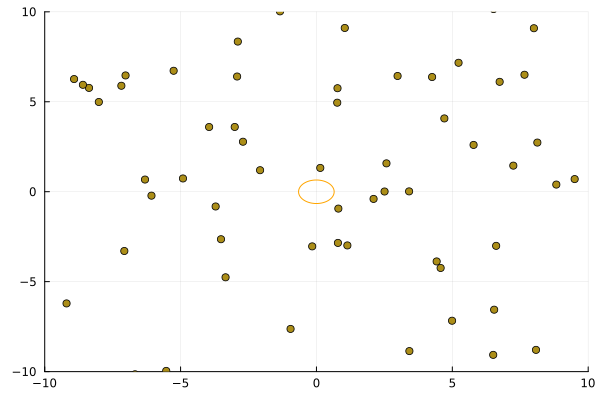

In [10]:
using Plots

function make_contour_plot(B::Polynomial, limits ::Tuple{Float64,Float64}, clr::String; x3_val=0.0, x4_val=0.0, x5_val=0.0, x6_val=0.0)
    x = range(limits[1], limits[2], length=500)
    y = range(limits[1], limits[2], length=500)
    my_fun(xa::Float64,ya::Float64) = B([xa, ya, x3_val, x4_val,x5_val, x6_val])
    z = @.my_fun(x', y)
    # Draw the certified boundary (0-level) and nearby level sets for visibility.
    contour!(x, y, z, levels=[0.0, 0.01, 0.02], color=clr, colorbar=false)
end

limits=(-10., 10.)
plot(xlims = limits, ylims = limits)
# make_contour_plot(g, limits,"red") 
make_contour_plot(B_1, limits, "black")
make_contour_plot(B_2, limits, "blue")
make_contour_plot(B_3, limits,"green")
make_contour_plot(B_4, limits, "orange")
plot!([x1 for (x1,_) in test_pts], [x2 for (_, x2) in test_pts], seriestype=:scatter, labels=false)


In [11]:
using LaTeXStrings
function circleShape(x,y, r)
    θ = LinRange(0, 2*π, 500)
    x .+ r*cos.(θ), y .+ r*sin.(θ)
end
function plot_ics_region(limits::Tuple{Float64,Float64}, all_barriers::Vector{<:Polynomial}; δ = 0.5, x3_val=10, x4_val=π/2,x5_val=1.,x6_val=0.)
    plot(xlims=limits, ylims=limits)
    rectangle(w, h, x, y) = Shape(x .+ [0,w,w,0], y .+ [0,0,h,h])
    pts = vec(collect(Iterators.product(limits[1]:δ:limits[2], limits[1]:δ:limits[2])))
    minB = [minimum(B(px, py, x3_val, x4_val, x5_val, x6_val) for B in all_barriers) for (px, py) in pts]
    has_strict_safe = any(v -> v <= 0.0, minB)
    thresh = 0.0
    fill_color = :green
    fill_label = "B <= 0"
    if !has_strict_safe
        # Fallback for difficult slices: show a near-safe band so the plot is informative.
        sorted_vals = sort(copy(minB))
        idx = max(1, Int(floor(0.08 * length(sorted_vals))))
        thresh = sorted_vals[idx]
        fill_color = :orange
        fill_label = "near-safe"
    end
    for ((px, py), v) in zip(pts, minB)
        if v <= thresh
            plot!(rectangle(δ, δ, px-δ, py-δ), label=false, fill=fill_color, opacity=0.45, linecolor=fill_color)
        end
    end
    plot!(circleShape(0,0,1.), seriestype =[:shape], lw=0.5, c=:black, linecolor=:black, legend=false, aspectratio=1  )
    plot!(xlims=limits, ylims=limits, title="Safe slice (x3=$(round(x3_val, digits=2)), x4=$(round(x4_val, digits=2)), x5=$(round(x5_val, digits=2)); $fill_label)")
end

plot_ics_region (generic function with 1 method)

In [12]:
all_barriers = [B_1, B_2, B_3, B_4]

4-element Vector{Polynomial{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, Graded{LexOrder}, Float64}}:
 0.019971597225316357 + 7.046616672101301e-7x₆ - 1.372658849361142e-8x₅ - 4.148608571159956e-9x₄ + 5.960692309705171e-8x₃ - 2.1363276567921514e-7x₂ - 2.1027324342578427e-7x₁ + 6.35480408933548e-6x₆² + 4.901201638377289e-8x₅x₆ + 9.674843062282325e-8x₅² - 1.8557646622872626e-7x₄x₆ - 5.27059894527594e-11x₄x₅ + 7.138962015644666e-8x₄² - 1.7190475575491965e-8x₃x₆ - 4.377597658513803e-9x₃x₅ + 8.056457299491753e-9x₃x₄ + 1.9282456521668155e-7x₃² - 2.0799288729513726e-8x₂x₆ - 2.2608228278760802e-8x₂x₅ - 2.3413425045657165e-7x₂x₄ - 6.217161655256213e-8x₂x₃ - 2.3463568971520562e-5x₂² + 1.1296801595871648e-7x₁x₆ + 6.2509802086552725e-9x₁x₅ - 2.1978168164794932e-8x₁x₄ - 1.180057814475396e-7x₁x₃ - 9.316291998245813e-8x₁x₂ - 2.328536067531916e-5x₁²
 0.019974487493124166 + 2.731472577092669e-7x₆ + 1.6733999836332872e-8x₅ + 3.0564002454766327e-9x₄ + 4.447765482288693e-8x₃ - 3.92809

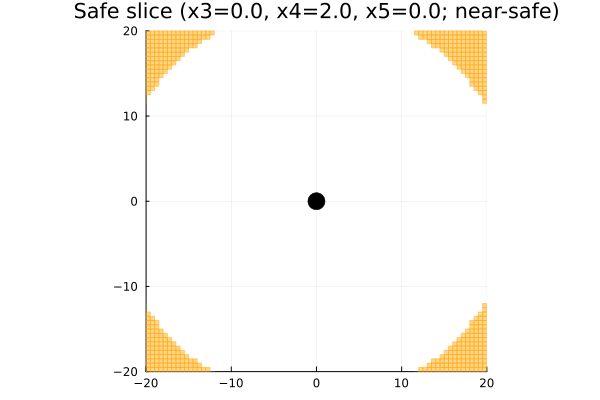

In [13]:
plot_ics_region((-20.0, 20.0), all_barriers; x3_val=0.0, x4_val=2.0, x5_val=0.0, x6_val=0.0)

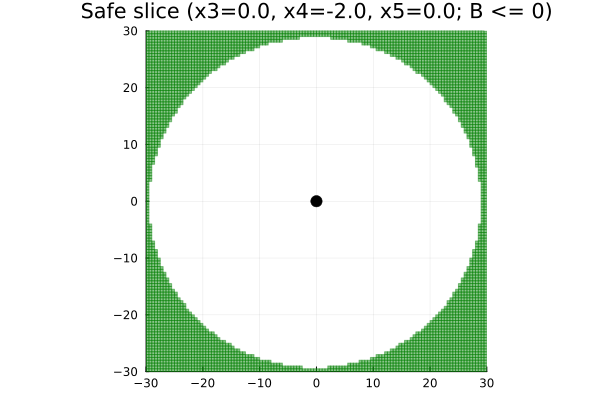

In [14]:
plot_ics_region((-30.0, 30.0), all_barriers; x3_val=0.0, x4_val=-2.0, x5_val=0.0, x6_val=0.0)

[ Info: Saved animation to /Users/rameez/workspace/moving_obs_barrier/figures/repulsive_hybrid_coordturn_moving_obstacle.gif


Simulation finished
minimum recentered barrier value = 0.006308042405314383
minimum true obstacle distance = 20.14147549441492
mean tracking error = 21.344783544753763
max tracking error = 42.68215903460981
number of barrier overrides = 400
Animation saved to figures/repulsive_hybrid_coordturn_moving_obstacle.gif


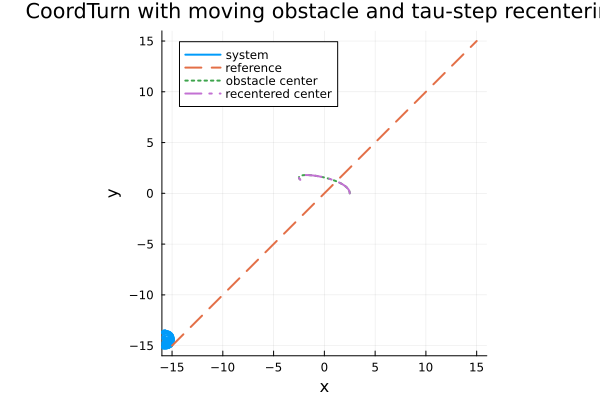

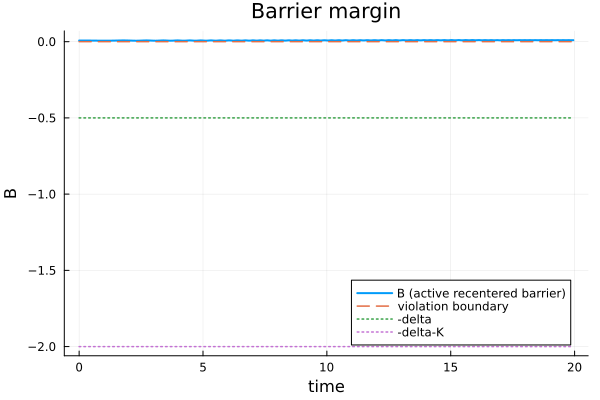

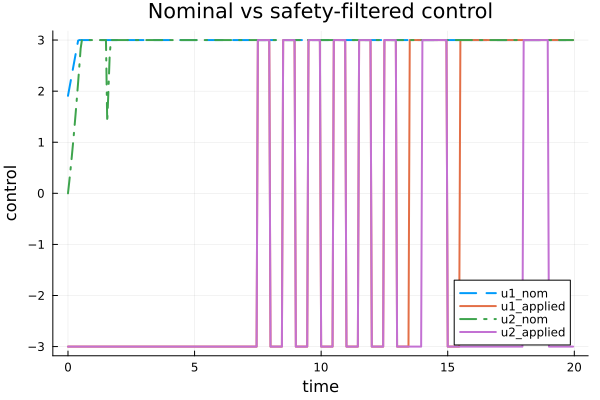

GIF saved to: figures/repulsive_hybrid_coordturn_moving_obstacle.gif


In [15]:
include("Repulsive_hybrid_CoordTurn_recenter_fix.jl")
barrier_controls = [(U[1][1], U[1][2]), (U[2][1], U[2][2]), (U[3][1], U[3][2]), (U[4][1], U[4][2])]
delta_sim = δ
K_sim = K
res = run_repulsive_hybrid_coordturn_demo(
    all_barriers;
    barrier_controls=barrier_controls,
    delta=delta_sim,
    k_override=K_sim,
    dt=0.05,
    T=20.0,
    tau_steps=10,
    x0=[-15.0, -15.0, 0.0, π/4, 0.0, 0.0],
    ref_start=[-15.0, -15.0],
    ref_end=[15.0, 15.0],
    ref_T=20.0,
)
display(res.p_traj); display(res.p_B); display(res.p_u)
println("GIF saved to: ", res.gif_path)